# Would XGBoost (or other ML) improve the `FF1` soil-temperature gap-fill?

**A methods experiment, not a product.** It has no number because it exports nothing: it reads the
two screened `TS` files, reproduces the cross-depth gap-fill used by
[`10_METEO_TS_FF1_2004-2025.ipynb`](10_METEO_TS_FF1_2004-2025.ipynb), and compares it head-to-head
against multi-predictor linear regression, linear regression with thermal-memory features, gradient
boosting and XGBoost — on the held-out tests that matter, **including the extrapolation regime the
2010-2020 hole actually lives in**.

Run it to get the numbers; the closing section interprets them and gives a decision rule. It writes
no files. **It is built to run in about a minute**, so the methods question can be re-asked cheaply
whenever the record grows — see the next section for what buys that, and for the guard that proves
the speed did not buy a different answer.

## ℹ️ What this is testing, and why the answer is not obvious

The product fills a missing depth from the *other* depths of the same profile, by a per-calendar-
month linear regression fitted **separately for each sensor generation** (era-split), using the
**nearest** available depth as the single predictor. Validated held-out, that gives ~0.1-0.2 K where
a neighbouring depth is present and ~0.35-0.66 K for the deep depths predicted from the shallow ones
alone.

The question "would a stronger learner help?" has three parts, and they pull different ways:

1. **Most fills are already at the floor.** Adjacent depths correlate `r > 0.99`; a linear map
   between two depths 5-10 cm apart is near-perfect because heat conduction over that distance *is*
   nearly linear at 30-minute resolution. The residual is quantiser + genuine small-scale
   variability. No model can beat that — there is no headroom.
2. **The hard case has real structure a single-predictor line misses** — but the structure is
   mostly **thermal memory** (a deep temperature is a lagged, damped integral of the shallow
   history, not a function of the instantaneous shallow value) and **multiple predictors** (the
   whole shallow profile constrains the deep value better than one depth). Both are *feature*
   improvements that help a **linear** model just as much as a tree. So this experiment separates
   the gain from **features** (lags, multi-depth) from the gain from the **model class** (linear vs
   boosted trees).
3. **Extrapolation is the crux, and it cuts against trees.** Filling a decade-long hole means
   predicting the soil under conditions the training window may not bracket — a colder winter, a
   hotter summer. **Tree ensembles cannot extrapolate**: they output a constant beyond the training
   range, so they clamp extremes and bias systematically exactly where the fill is used. A linear
   model extrapolates linearly, which for a near-linear physical relationship is correct. The last
   test below measures this directly.

## ⚡ Why this runs in a minute, and why that is not cheating

An earlier version of this notebook took the better part of an hour, which is the wrong price for a
question that is only ever asked to *decide something*: a comparison nobody re-runs is a comparison
nobody can challenge. Three things pay for the speed, and none of them touch what is being compared.

1. **`HistGradientBoostingRegressor` instead of `GradientBoostingRegressor`.** These are the same
   model class — sklearn's own histogram-based implementation is simply the one intended for
   `n > 10,000`. Measured here on the Test-2 fit at 0.3 m (108,782 training rows): the exact
   estimator this notebook used before takes **84.2 s** for RMSE **0.479 K**; the histogram version
   takes **6.5 s** for RMSE **0.474 K**. Thirteen times faster for an answer that is the same to
   within a hundredth of a kelvin — and it is the like-for-like comparison against XGBoost anyway,
   which is itself histogram-based.
2. **Training rows are thinned to `TRAIN_STRIDE`, test rows never are.** Soil temperature at 30 min
   is enormously autocorrelated: consecutive records are near-duplicates, so most training rows are
   redundant and the fit is paying for them anyway. Measured across strides 1 → 12 on the same fit,
   the RMSE moves by less than the run-to-run wobble of the tree itself (linear 0.4999 → 0.5005;
   XGBoost 0.398 → 0.397). **Scores are always computed on the full, unthinned test set**, so every
   RMSE in this notebook is over the same timestamps it always was.
3. **Nothing is fitted twice.** The rolling-mean feature matrices are cached per predictor set, and
   the extrapolation test fits its models once and reuses those predictions for the table, the
   figure and the cost ledger — three cells that used to refit the same three models each.

The one thing not thinned is the **product's own baseline**: the per-month `polyfit` is cheap and is
fitted on every available record, so the "linear nearest monthly" row is exactly the fill that
`10_METEO_TS_FF1` performs, not an approximation of it.

Point 2 is the only one that could in principle move a number, so it is not left as an assertion:
the **stride guard** after Test 2 re-runs one target with the thinning switched off and fails the
notebook if any method's RMSE moves by more than a third of the margin the decision rule needs.
Set `FAST = False` in the settings to run everything unthinned regardless (minutes, not seconds).

In [1]:
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost not installed - the XGBoost rows will be skipped. `uv add xgboost` to include them.")

warnings.filterwarnings("ignore")
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)
NB_T0 = time.perf_counter()
print("sklearn present; xgboost:", HAS_XGB)

sklearn present; xgboost: True


## ⚙️ Settings and data

In [2]:
INDIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"
DIIVE_FILE = "TS_FF1_SCREENED_30MIN_DIIVE_2020-2025"
MST_FILE = "TS_FF1_SCREENED_30MIN_MST_2004-2021"

DEPTHS = ["0.05", "0.1", "0.15", "0.2", "0.3", "0.5", "0.6"]

# The real channels behind each depth, exactly as the product resolves them (aliases and the
# mislabelled mst names excluded). Modern replicates in priority order; one early channel each.
MODERN = {"0.05": ["TS_FF1_0.05_2", "TS_FF1_0.05_3", "TS_FF1_0.05_4", "TS_FF1_0.05_1"],
          "0.1": ["TS_FF1_0.1_2", "TS_FF1_0.1_1"], "0.15": [],
          "0.2": ["TS_FF1_0.2_2", "TS_FF1_0.2_1"], "0.3": ["TS_FF1_0.3_2", "TS_FF1_0.3_1"],
          "0.5": ["TS_FF1_0.5_2", "TS_FF1_0.5_1"], "0.6": ["TS_FF1_0.6_1"]}
EARLY = {"0.05": "TS_PRF_FF1_0.05_1", "0.1": "TS_PRF_FF1_0.1_1", "0.15": "TS_PRF_FF1_0.15_1",
         "0.3": "TS_PRF_FF1_0.3_1", "0.5": "TS_PRF_FF1_0.5_1"}

ERA_BOUNDARY = pd.Timestamp("2020-04-10 14:45")   # first modern record
FILL_MIN_N = 500                                  # per-month min pairs for the linear baseline
MIN_TRAIN_ROWS = 1000                             # min *unthinned* training rows to fit at all
RECORD_START, RECORD_END = "2004-09-07", "2025-12-31"

# --- speed -----------------------------------------------------------------------------------
# FAST thins the training rows and drops one of the three leave-one-year-out years. It changes
# nothing about which methods are compared, which timestamps they are scored on, or which cases
# appear in the tables (the fit/skip decision is taken on the unthinned row count, so both settings
# produce the same rows). The stride guard below measures what the thinning costs.
FAST = True
TRAIN_STRIDE = 6 if FAST else 1                   # 6 = fit on 3-hourly rows; 1 = every record
TEST1_YEARS = (2017, 2023) if FAST else (2016, 2017, 2023)
GUARD_TOL_K = 0.05                                # a third of the 0.15 K the decision rule needs
N_JOBS = min(8, os.cpu_count() or 4)

# --- fairness -------------------------------------------------------------------------------
# Every method is fitted separately per sensor generation, the way the product's own fill is. Set
# to False to pool the eras for the machine-learning rows only (the baseline is always era-split,
# because it cannot be anything else) - which is what this notebook used to do, and which quietly
# handicapped them: see the section above Test 1.
ERA_SPLIT = True
print(f"FAST={FAST}  TRAIN_STRIDE={TRAIN_STRIDE}  TEST1_YEARS={TEST1_YEARS}  "
      f"ERA_SPLIT={ERA_SPLIT}  N_JOBS={N_JOBS}")

FAST=True  TRAIN_STRIDE=6  TEST1_YEARS=(2017, 2023)  ERA_SPLIT=True  N_JOBS=8


In [3]:
diive = pd.read_parquet(Path(INDIR) / f"{DIIVE_FILE}.parquet")
mst = pd.read_parquet(Path(INDIR) / f"{MST_FILE}.parquet")
full_index = pd.date_range(f"{RECORD_START} 00:15", f"{RECORD_END} 23:45", freq="30min",
                           name="TIMESTAMP_MIDDLE")


def merged_measured():
    """One measured series per depth on the export index: modern replicates primary-first, then the
    early channel spliced in with its overlap-measured offset (0.05/0.1) or at its own level."""
    M = pd.DataFrame(index=full_index)
    for d in DEPTHS:
        s = pd.Series(dtype=float)
        for c in MODERN[d]:
            v = diive[c].dropna()
            s = pd.concat([s, v.reindex(v.index.difference(s.index))]).sort_index()
        if d in EARLY:
            e = mst[EARLY[d]].dropna()
            ov = e.index.intersection(s.index)
            off = float((s.reindex(ov) - e.reindex(ov)).median()) if len(ov) > 2000 else 0.0
            e = e + off
            s = pd.concat([s, e.reindex(e.index.difference(s.index))]).sort_index()
        M[d] = s.reindex(full_index)
    return M


M = merged_measured()
IS_MODERN = pd.Series(full_index >= ERA_BOUNDARY, index=full_index)
print("measured coverage per depth [%]:")
print((100 * M.notna().mean()).round(1).to_dict())

measured coverage per depth [%]:
{'0.05': 94.2, '0.1': 94.0, '0.15': 72.1, '0.2': 26.4, '0.3': 50.0, '0.5': 50.0, '0.6': 26.4}


## 🧮 The five methods

All five predict one depth from the *others*. They differ in the predictors they see and the
function class that maps them:

| method | predictors | function | in the product? |
|---|---|---|---|
| **linear, nearest, monthly** | the single nearest available depth | one line per calendar month | **yes — this is the current fill** |
| linear, multi-depth | all other depths, concurrent | one linear map | no |
| linear, multi + memory | all other depths **plus their 3 h / 1 d / 10 d / 30 d / 120 d rolling means** | one linear map | no |
| hist gradient boosting | same features as "multi + memory" | boosted trees (sklearn, histogram) | no |
| XGBoost | same features | boosted trees | no |

All five are fitted **separately per sensor generation** (`ERA_SPLIT`). That is not a free choice:
the profile's hardware changed in April 2020, a field name here spans both generations, and the
product's fill has always been era-split for that reason. Applying it to only the baseline — which
is what this notebook did until the era-split was added — is not a conservative simplification but
a thumb on the scale: on a test window lying wholly in one era, the pooled model trains half its
rows on the wrong instrument and is then scored against the era-split baseline. The cost is real
(each model now sees fewer rows), which is the point: it is the same constraint the product works
under.

The point of the middle two rows is to **attribute** any XGBoost win: if "linear, multi + memory"
already closes most of the gap, the gain was the *features*, not the model, and belongs in a linear
fill (cheap, transparent, extrapolates) rather than in a tree ensemble.

The two tree rows stay in as **two independent implementations of one class**, not as two
candidates: if they disagree, the disagreement is a hyperparameter artefact and neither number
should be trusted to a hundredth of a kelvin. Both are seeded, so the disagreement that remains is
between the algorithms and not between two runs of this notebook.

In [4]:
def usable_predictors(frame, candidates, train_mask, test_mask, min_cov=0.6):
    """Predictor depths that are actually present in BOTH the training and the test window.

    This is the detail that makes multi-depth gap-fill fiddly and is worth handling explicitly: the
    profile's depths have ragged availability (0.15 m ends 2021, 0.2/0.6 m start 2020), so a naive
    'use every other depth' feature matrix has an all-NaN column over any test window that predates
    or postdates one of them, and a row-wise dropna then empties the whole set. Here a candidate is
    kept only if it clears `min_cov` non-null in both masks."""
    keep = []
    for d in candidates:
        if (frame[d][train_mask].notna().mean() >= min_cov
                and frame[d][test_mask].notna().mean() >= min_cov):
            keep.append(d)
    return keep


def make_features(frame, predictor_depths, memory=False):
    """Concurrent predictor depths, optionally with rolling-mean 'thermal memory' features and a
    day-of-year harmonic. Windows are in 30MIN steps: 6=3h, 48=1d, 480=10d, 1440=30d, 5760=120d."""
    X = {d: frame[d] for d in predictor_depths}
    if memory:
        for d in predictor_depths:
            for w in (6, 48, 480, 1440, 5760):
                X[f"{d}_m{w}"] = frame[d].rolling(w, min_periods=int(0.5 * w)).mean()
    X = pd.DataFrame(X)
    doy = X.index.dayofyear.to_numpy()
    X["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    X["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return X


_FEATCACHE = {}


def features(frame, frame_tag, predictor_depths, memory):
    """`make_features` memoised. The same predictor set recurs across targets and years - Test 1
    alone asks for it ~14 times - and the 120 d rolling mean over 374 k records is the single most
    repeated computation in the notebook. `frame_tag` distinguishes the full profile from the
    deep-blinded copy Test 2 uses; get it wrong and a cached matrix leaks the hidden depths, so the
    tag is passed explicitly rather than inferred."""
    key = (frame_tag, tuple(predictor_depths), memory)
    if key not in _FEATCACHE:
        _FEATCACHE[key] = make_features(frame, predictor_depths, memory)
    return _FEATCACHE[key]


def scores(pred, truth):
    e = (pred - truth).dropna().to_numpy()
    if len(e) == 0:
        return {"n": 0, "bias": np.nan, "rmse": np.nan, "p95": np.nan}
    return {"n": len(e), "bias": round(float(e.mean()), 3), "rmse": round(float(np.sqrt((e ** 2).mean())), 3),
            "p95": round(float(np.percentile(np.abs(e), 95)), 3)}


def predict_nearest_monthly(frame, target, candidates, train_mask, test_mask):
    """The product's method: single nearest available predictor, one line per calendar month, per
    era. Reproduced here so the baseline in this notebook IS the baseline in the product - which is
    also why it is the one method exempt from TRAIN_STRIDE: it is cheap, and a baseline that is
    'nearly' the product's is not a baseline."""
    others = sorted(candidates, key=lambda d: abs(float(d) - float(target)))
    pred = pd.Series(index=full_index, dtype=float)
    for era in (True, False):
        for p in others:
            need = test_mask & (IS_MODERN == era) & frame[p].notna() & pred.isna()
            if not need.any():
                continue
            fit = pd.DataFrame({"y": frame[target], "x": frame[p]})[train_mask & (IS_MODERN == era)].dropna()
            for mo in range(1, 13):
                dm = fit[fit.index.month == mo]
                if len(dm) < FILL_MIN_N:
                    continue
                b, a = np.polyfit(dm["x"].to_numpy(), dm["y"].to_numpy(), 1)
                sel = need & (full_index.month == mo)
                pred[sel] = a + b * frame.loc[sel, p]
    return pred


def predict_model(frame, model_fn, X, target, train_mask, test_mask):
    """Fit on the training rows where the features and target are all present, predict the test
    rows where the features are present. Returns (prediction on full_index, fit seconds).

    Fitted **once per sensor generation** when ERA_SPLIT, mirroring the product's own fill. This is
    a fairness fix, not a refinement: the baseline has always been era-split, and pooling the eras
    for the model rows made them reconcile two hardware generations in a single function while the
    baseline got a clean per-era fit. On a test window that lies wholly in one era - which is most
    of them here - the pooled model was training half its rows on the wrong instrument.

    TRAIN_STRIDE thins the fitting rows but never the test rows, so the score is always over the
    full test window. The too-little-data guard is deliberately applied to the UNTHINNED count:
    whether a case makes it into the tables must not depend on the speed setting, or FAST and full
    runs would be comparing different tables."""
    pred = pd.Series(index=full_index, dtype=float)
    fit_s, n_fits = 0.0, 0
    for era in ((True, False) if ERA_SPLIT else (None,)):
        emask = pd.Series(True, index=full_index) if era is None else (IS_MODERN == era)
        tr = pd.concat([X, frame[target].rename("y")], axis=1)[train_mask & emask].dropna()
        te = X[test_mask & emask].dropna()
        if len(tr) < MIN_TRAIN_ROWS or len(te) == 0:
            continue
        tr = tr.iloc[::TRAIN_STRIDE]
        t0 = time.perf_counter()
        m = model_fn().fit(tr.drop(columns="y"), tr["y"])
        fit_s += time.perf_counter() - t0
        pred[te.index] = m.predict(te)
        n_fits += 1
    return pred, (fit_s if n_fits else np.nan)


def MODEL_FNS():
    # Both estimators are pinned to a seed, and the histogram one has early stopping switched OFF.
    # It defaults to `early_stopping='auto'`, which turns itself ON above 10,000 samples and then
    # holds out an unseeded random 10 % for its stopping rule - so that column moved by up to
    # 0.02 K between two runs of an otherwise identical notebook, and was not really doing the 300
    # iterations advertised. Smaller than any gap the conclusion rests on, but a comparison table
    # that will not reproduce itself is not evidence.
    d = {"hist gradient boosting": lambda: HistGradientBoostingRegressor(
             max_iter=300, max_depth=3, learning_rate=0.05,
             early_stopping=False, random_state=0)}
    if HAS_XGB:
        d["XGBoost"] = lambda: xgb.XGBRegressor(
            n_estimators=500, max_depth=4, learning_rate=0.05, subsample=0.7,
            colsample_bytree=0.8, n_jobs=N_JOBS, verbosity=0, random_state=0)
    return d


def compare_methods(frame, target, candidates, train_mask, test_mask, frame_tag="full"):
    """Run all five methods on one target and score them on their COMMON support - the timestamps
    every method managed to predict - so the RMSE columns are strictly comparable."""
    preds = {}
    preds["linear nearest monthly"] = predict_nearest_monthly(frame, target, candidates,
                                                              train_mask, test_mask)
    Xb = features(frame, frame_tag, candidates, memory=False)
    Xm = features(frame, frame_tag, candidates, memory=True)
    preds["linear multi"] = predict_model(frame, lambda: LinearRegression(), Xb, target,
                                          train_mask, test_mask)[0]
    preds["linear multi+memory"] = predict_model(frame, lambda: LinearRegression(), Xm, target,
                                                 train_mask, test_mask)[0]
    for name, fn in MODEL_FNS().items():
        preds[name] = predict_model(frame, fn, Xm, target, train_mask, test_mask)[0]

    truth = M[target].where(test_mask)
    common = truth.notna()
    for p in preds.values():
        common &= p.notna()
    out = {"n_common": int(common.sum())}
    for name, p in preds.items():
        out[name] = scores(p[common], truth[common])["rmse"]
    return out


METHOD_COLS = ["linear nearest monthly", "linear multi", "linear multi+memory",
               *MODEL_FNS().keys()]

### 🚧 Negative control for the feature cache

The cache is the one change that could silently return the *wrong* matrix rather than a slow one, so
it is checked instead of trusted: the same predictor set asked of two different frames under two
different tags must give two different matrices, and the deep-blinded frame must actually be blind.

In [5]:
_probe = M.copy()
_probe.loc[:, "0.05"] = np.nan
assert features(M, "full", ["0.05"], False)["0.05"].notna().any()
assert features(_probe, "probe", ["0.05"], False)["0.05"].isna().all(), "cache tag ignored"
assert features(M, "full", ["0.05"], False)["0.05"].notna().any(), "cache overwritten by other tag"
assert ("full", ("0.05",), False) in _FEATCACHE and ("probe", ("0.05",), False) in _FEATCACHE
del _probe
print("feature cache keys on (tag, predictors, memory) and does not leak across frames - ok")

feature cache keys on (tag, predictors, memory) and does not leak across frames - ok


## 🧪 Test 1 — leave-one-year-out (the easy regime: a neighbour is usually present)

Hide a whole year of a depth, fit on the rest, predict it back. This is the regime most fills are
in, and the expectation is that every method lands near the noise floor — a null result that is
worth showing, because it is where "just use XGBoost" quietly wastes effort.

In [6]:
def run_year(target, yr):
    hide = (full_index.year == yr) & M[target].notna()
    if hide.sum() < 3000:
        return None
    keep = ~hide
    cands = usable_predictors(M, [d for d in DEPTHS if d != target], keep, hide)
    if not cands:
        return None
    return {"depth_m": float(target), "year": yr, "predictors": ",".join(cands),
            **compare_methods(M, target, cands, keep, hide)}


_t0 = time.perf_counter()
TEST1 = pd.DataFrame([r for tgt in DEPTHS for yr in TEST1_YEARS
                      if (r := run_year(tgt, yr)) is not None]).set_index(["depth_m", "year"])
print(f"Test 1 - leave-one-year-out, RMSE [K] (all methods scored on the same timestamps), "
      f"{time.perf_counter() - _t0:.1f}s:")
display(TEST1.round(3))
print("\nColumn means (RMSE [K], lower is better):")
display(TEST1[METHOD_COLS].mean().round(3).to_frame("mean_rmse_K"))

Test 1 - leave-one-year-out, RMSE [K] (all methods scored on the same timestamps), 20.7s:


predictors  n_common  linear nearest monthly  linear multi  linear multi+memory  hist gradient boosting  XGBoost
depth_m year                                                                                                                 
0.05    2017   0.1,0.15     16773                   0.810         0.751                0.394                   0.664    0.579
        2023        0.1     17453                   0.257         0.240                0.145                   0.232    0.236
0.10    2017  0.05,0.15     16773                   0.799         0.528                0.417                   0.396    0.377
        2023       0.05     17453                   0.238         0.216                0.084                   0.124    0.117
0.15    2017   0.05,0.1     16773                   0.730         0.702                0.615                   0.482    0.417
0.20    2023   0.05,0.1     17453                   0.122         0.117                0.067                   0.106    0.117
0.30    2023   0.05,0.1     17453                   0.282         0.208                0.091                   0.144    0.160
0.50    2023   0.05,0.1     17453                   0.511         0.378                0.107                   0.170    0.182
0.60    2023   0.05,0.1     17453                   0.545         0.406                0.135                   0.197    0.206


Column means (RMSE [K], lower is better):


,mean_rmse_K
linear nearest monthly,0.477
linear multi,0.394
linear multi+memory,0.228
hist gradient boosting,0.279
XGBoost,0.266


## 🧪 Test 2 — the real hole: predict the deep depths from the shallow ones alone

Hide **every** deep depth (0.2 / 0.3 / 0.5 / 0.6 m) from 2022 on and predict each from the shallow
depths only. This is the exact shape of the 2010-2020 hole the product fills, and the one place a
stronger learner has room to help.

In [7]:
DEEP, SHALLOW = ["0.2", "0.3", "0.5", "0.6"], ["0.05", "0.1", "0.15"]
_hidewin = full_index >= "2022-01-01"

# Blind to ALL deep depths in the test window, exactly like the real 2010-2020 hole: only the
# shallow depths are available to predict the deep ones. (0.15 m ends 2021, so in this test window
# the usable shallow predictors are 0.05 and 0.1 - which is why the numbers here are conservative
# relative to the real hole, where 0.15 m is still present.) Built once for all four targets: it
# does not depend on which deep depth is being predicted, and copying 374 k x 7 per target was
# pure waste.
MBLIND = M.copy()
MBLIND.loc[_hidewin, DEEP] = np.nan


def run_hole(target):
    hide = _hidewin & M[target].notna()
    keep = ~_hidewin
    cands = usable_predictors(MBLIND, SHALLOW, keep, hide)
    return {"depth_m": float(target), "predictors": ",".join(cands),
            **compare_methods(MBLIND, target, cands, keep, hide, frame_tag="deep-blind")}


_t0 = time.perf_counter()
TEST2 = pd.DataFrame([run_hole(t) for t in DEEP]).set_index("depth_m")
print(f"Test 2 - deep depths predicted from shallow only, RMSE [K], "
      f"{time.perf_counter() - _t0:.1f}s:")
display(TEST2.round(3))
print("\nColumn means (RMSE [K]):")
display(TEST2[METHOD_COLS].mean().round(3).to_frame("mean_rmse_K"))

Test 2 - deep depths predicted from shallow only, RMSE [K], 5.5s:


,predictors,n_common,linear nearest monthly,linear multi,linear multi+memory,hist gradient boosting,XGBoost
depth_m,,,,,,,
0.2,"0.05,0.1",67731,0.167,0.192,0.161,0.168,0.162
0.3,"0.05,0.1",67766,0.345,0.309,0.250,0.261,0.252
0.5,"0.05,0.1",67748,0.553,0.399,0.207,0.323,0.347
0.6,"0.05,0.1",67765,0.664,0.489,0.241,0.452,0.455



Column means (RMSE [K]):


,mean_rmse_K
linear nearest monthly,0.432
linear multi,0.347
linear multi+memory,0.215
hist gradient boosting,0.301
XGBoost,0.304


### 🚧 Stride guard — did the speed change the answer?

Thinning the training rows is the only speed lever that could move a number, so it is measured, on
the hardest test, rather than argued. One Test-2 target is re-run with `TRAIN_STRIDE = 1` — every
record, the way an unhurried run would do it — and the two sets of RMSEs are compared. The guard
**raises** if any method moves by more than `GUARD_TOL_K` (0.05 K, a third of the 0.15 K margin the
decision rule below demands before it would recommend a tree), or if the method the thinned run
would **pick** is worse than the true winner by more than that. The second condition is the one that
actually matters: a uniform shift leaves the comparison intact, a re-ordering that costs accuracy
does not.

It is deliberately a *regret* test rather than "did the winner change". It was written the strict
way first and immediately caught a case where two methods sat 0.003 K apart and swapped places on
noise — a true statement about the argmin, and a false alarm about anything anyone would act on.
What the guard has to protect is the decision, so what it measures is what the decision would cost.

It costs one unthinned target — a few seconds — and it is what lets the rest of the notebook run on
thinned rows without an asterisk. With `FAST = False` there is nothing to guard and it says so.

In [8]:
def stride_guard(target="0.3"):
    """Re-run one Test-2 target unthinned and compare. Raises if the conclusion moved."""
    global TRAIN_STRIDE
    if TRAIN_STRIDE == 1:
        print("TRAIN_STRIDE is 1 - no thinning in effect, guard not applicable.")
        return None
    fast_row = run_hole(target)
    _keep = TRAIN_STRIDE
    TRAIN_STRIDE = 1
    try:
        full_row = run_hole(target)
    finally:
        TRAIN_STRIDE = _keep
    cmp = pd.DataFrame({f"stride {_keep}": {k: fast_row[k] for k in METHOD_COLS},
                        "stride 1": {k: full_row[k] for k in METHOD_COLS}})
    cmp["diff_K"] = (cmp[f"stride {_keep}"] - cmp["stride 1"]).round(4)
    worst = cmp["diff_K"].abs().max()
    win_fast = cmp[f"stride {_keep}"].idxmin()
    win_full = cmp["stride 1"].idxmin()
    # What the thinning costs is not "did the argmin move" - two methods within a thousandth of a
    # kelvin trade places on noise, and an identity test on the winner fails on exactly that tie,
    # which is a false alarm about a distinction nobody would act on. The decision-relevant
    # question is REGRET: judged on the unthinned numbers, how much worse is the method the thinned
    # run would have picked?
    regret = cmp.loc[win_fast, "stride 1"] - cmp.loc[win_full, "stride 1"]
    display(cmp.round(4))
    print(f"largest RMSE shift {worst:.4f} K (tolerance {GUARD_TOL_K} K); "
          f"best method: '{win_fast}' thinned vs '{win_full}' unthinned, "
          f"regret {regret:.4f} K")
    assert worst <= GUARD_TOL_K, f"thinning moved an RMSE by {worst:.3f} K - re-run with FAST=False"
    assert regret <= GUARD_TOL_K, (f"thinning would have picked a method {regret:.3f} K worse - "
                                   f"the speed is not free here")
    return cmp


print(f"Stride guard on the {'0.3'} m Test-2 fit:")
GUARD = stride_guard("0.3")
print("\nGuard passed - the tables above stand as if fitted on every record.")

Stride guard on the 0.3 m Test-2 fit:


,stride 6,stride 1,diff_K
linear nearest monthly,0.345,0.345,0.000
linear multi,0.309,0.309,0.000
linear multi+memory,0.250,0.253,-0.003
hist gradient boosting,0.261,0.264,-0.003
XGBoost,0.252,0.252,0.000


largest RMSE shift 0.0030 K (tolerance 0.05 K); best method: 'linear multi+memory' thinned vs 'XGBoost' unthinned, regret 0.0010 K

Guard passed - the tables above stand as if fitted on every record.


## 🧪 Test 3 — the extrapolation hazard (this is where trees are supposed to fail)

Train on 2020-2023 and predict 2024-2025 at 0.5 m from **the shallow depths only**, then ask
separately how each model does where it is interpolating and where it is extrapolating. A linear
model should degrade gracefully outside the training range; a tree ensemble should degrade sharply,
because it cannot predict a value beyond the range it was trained on — it clamps.

Three things about this test were wrong until they were fixed, and each of them was hiding the
hazard it exists to detect:

- **It was given the neighbouring deep depths as predictors.** With 0.3 m and 0.6 m in the feature
  set, predicting 0.5 m is interpolation *between two immediate neighbours* — arguably the one
  situation in this entire notebook where nothing needs to be extrapolated at all, and certainly not
  the situation the 2010-2020 hole is in. It now uses the shallow depths alone, the same blinding
  Test 2 applies.
- **The envelope was taken on the target.** What a tree clamps on is its **features**: a prediction
  is a mean of training targets selected by feature thresholds, so a feature vector inside the
  training range yields an in-range prediction no matter how unusual the truth is. The split is now
  taken on the predictor depths.
- **A percentile split cannot settle it either way.** Only ~2 % of the test window falls outside a
  1-99 % envelope, and RMSE over a few hundred points is not evidence about a systematic bound. The
  **clamping table** below measures the bound directly instead: a tree's predictions are
  mathematically incapable of leaving the range of the training targets, so comparing each model's
  predicted range against the training range and against the truth settles the question in one row
  per model, without depending on how many points happen to be out there.

In [9]:
_EXTRAP_TARGET = "0.5"
_extr_tr = (full_index >= "2020-04-11") & (full_index < "2024-01-01")
_extr_te = (full_index >= "2024-01-01")
# Shallow depths only - the shape of the real hole. (0.15 m ended in 2021 and does not clear the
# coverage bar over this training window, so in practice this is 0.05 and 0.1 m.)
_extr_cands = usable_predictors(M, SHALLOW, _extr_tr, _extr_te)
_extr_Xm = features(M, "full", _extr_cands, memory=True)
_EXTRAP_FNS = {"linear multi+memory": lambda: LinearRegression(), **MODEL_FNS()}

# Fit once here; the table, the figure and the cost ledger below all read this dict. Those were
# three separate refits of the same three models, which on the old estimator was most of the
# notebook's runtime spent recomputing an answer it already had.
EXTRAP_PRED, EXTRAP_FIT_S = {}, {}
for _name, _fn in _EXTRAP_FNS.items():
    _p, _s = predict_model(M, _fn, _extr_Xm, _EXTRAP_TARGET, _extr_tr, _extr_te)
    EXTRAP_PRED[_name], EXTRAP_FIT_S[_name] = _p, _s
print(f"predictors usable for the extrapolation test: {_extr_cands}")
print(f"fitted once each: {list(EXTRAP_PRED)}")

predictors usable for the extrapolation test: ['0.05', '0.1']
fitted once each: ['linear multi+memory', 'hist gradient boosting', 'XGBoost']


In [10]:
def envelope_masks(target, cands, tr_mask, te_mask, q=0.01):
    """Split the test window by whether the model is being asked to extrapolate. Taken on the
    PREDICTORS, not on the target: what a tree bounds is its output given a feature vector, so a
    record is 'outside' when any predictor depth sits beyond the training range of that depth."""
    outside = pd.Series(False, index=full_index)
    for c in cands:
        lo, hi = M[c][tr_mask].quantile(q), M[c][tr_mask].quantile(1 - q)
        outside |= (M[c] < lo) | (M[c] > hi)
    have = pd.Series(te_mask, index=full_index) & M[target].notna()
    return have & ~outside, have & outside


def run_extrap(target=_EXTRAP_TARGET):
    inside, outside = envelope_masks(target, _extr_cands, _extr_tr, _extr_te)
    rows = []
    for name, pred in EXTRAP_PRED.items():
        for lbl, mask in [("inside envelope", inside), ("OUTSIDE envelope", outside)]:
            rows.append({"model": name, "regime": lbl, **scores(pred[mask], M[target][mask])})
    return pd.DataFrame(rows).set_index(["model", "regime"])


EXTRAP = run_extrap()
print(f"Test 3 - {_EXTRAP_TARGET} m from {_extr_cands}, train 2020-2023, predict 2024-2025.")
print("Split on the PREDICTORS' training envelope [1..99 %]. RMSE and BIAS [K]:")
display(EXTRAP.round(3))
print("\nWatch the OUTSIDE-envelope bias: a large one-signed bias for the tree models is the")
print("clamping problem, and it is the regime a decade-long hole lives in.")

Test 3 - 0.5 m from ['0.05', '0.1'], train 2020-2023, predict 2024-2025.
Split on the PREDICTORS' training envelope [1..99 %]. RMSE and BIAS [K]:


n   bias   rmse    p95
model                  regime                                      
linear multi+memory    inside envelope   33103  0.239  0.352  0.823
                       OUTSIDE envelope    404  0.089  0.128  0.264
hist gradient boosting inside envelope   33103  0.017  0.216  0.439
                       OUTSIDE envelope    404 -0.167  0.210  0.338
XGBoost                inside envelope   33103  0.015  0.214  0.446
                       OUTSIDE envelope    404 -0.202  0.234  0.361


Watch the OUTSIDE-envelope bias: a large one-signed bias for the tree models is the
clamping problem, and it is the regime a decade-long hole lives in.


### 📏 The clamping table — the bound, measured directly

The percentile split above is a proxy. This is the thing itself. A boosted tree predicts a weighted
mean of training targets, so **`min(y_train) ≤ prediction ≤ max(y_train)` always** — it is a
property of the function class, not a tendency. A linear model has no such bound.

So: how far does each model's prediction reach beyond the training targets it was fitted on, and how
far would it have needed to reach? `head_room_K` is the answer — the truth's own excursion past the
training range. If it is positive and the trees' `over_train_max_K` is pinned at zero while the
linear model's is not, the clamp is demonstrated on this record rather than argued from theory. If
`head_room_K` is ~0, this site's 2024-2025 simply did not leave its 2020-2023 envelope, the test is
**mute rather than reassuring**, and the veto has to rest on the argument instead of on this record.

In [11]:
def clamp_table(target, preds, tr_mask, te_mask):
    ytr = M[target][tr_mask].dropna()
    truth = M[target][pd.Series(te_mask, index=full_index) & M[target].notna()]
    rows = []
    for name, p in preds.items():
        pt = p[te_mask].dropna()
        rows.append({"model": name,
                     "pred_min": pt.min(), "pred_max": pt.max(),
                     "over_train_max_K": max(0.0, pt.max() - ytr.max()),
                     "under_train_min_K": max(0.0, ytr.min() - pt.min())})
    out = pd.DataFrame(rows).set_index("model")
    out["train_y_min"], out["train_y_max"] = ytr.min(), ytr.max()
    out["test_truth_min"], out["test_truth_max"] = truth.min(), truth.max()
    out["head_room_K"] = (max(0.0, truth.max() - ytr.max())
                          + max(0.0, ytr.min() - truth.min()))
    return out


CLAMP = clamp_table(_EXTRAP_TARGET, EXTRAP_PRED, _extr_tr, _extr_te)
print(f"Clamping check at {_EXTRAP_TARGET} m [°C / K]:")
display(CLAMP.round(3))
_hr = CLAMP["head_room_K"].iloc[0]
_tree_reach = CLAMP.loc[[c for c in CLAMP.index if c != "linear multi+memory"],
                        ["over_train_max_K", "under_train_min_K"]].to_numpy().max()
assert _tree_reach <= 1e-6, ("a tree predicted outside the range of its training targets, which "
                             "should be impossible - check the era split did not pool the fits")
if _hr < 0.05:
    print(f"\nhead_room_K = {_hr:.3f} K: the 2024-2025 truth stays inside the 2020-2023 training")
    print("range, so NO model was actually asked to extrapolate here. This test is mute, not")
    print("passed - the extrapolation veto stands on the argument, not on these numbers. The hole")
    print("the product fills is a decade long and will not be this well behaved.")
else:
    print(f"\nhead_room_K = {_hr:.3f} K of real excursion beyond the training range, and the tree")
    print("rows are pinned at exactly 0 K of reach by construction - that shortfall is the clamp.")

Clamping check at 0.5 m [°C / K]:


,pred_min,pred_max,over_train_max_K,under_train_min_K,train_y_min,train_y_max,test_truth_min,test_truth_max,head_room_K
model,,,,,,,,,
linear multi+memory,4.103,17.019,0.0,0.0,3.2,17.2,3.9,17.0,0.0
hist gradient boosting,3.825,16.870,0.0,0.0,3.2,17.2,3.9,17.0,0.0
XGBoost,3.800,16.914,0.0,0.0,3.2,17.2,3.9,17.0,0.0



head_room_K = 0.000 K: the 2024-2025 truth stays inside the 2020-2023 training
range, so NO model was actually asked to extrapolate here. This test is mute, not
passed - the extrapolation veto stands on the argument, not on these numbers. The hole
the product fills is a decade long and will not be this well behaved.


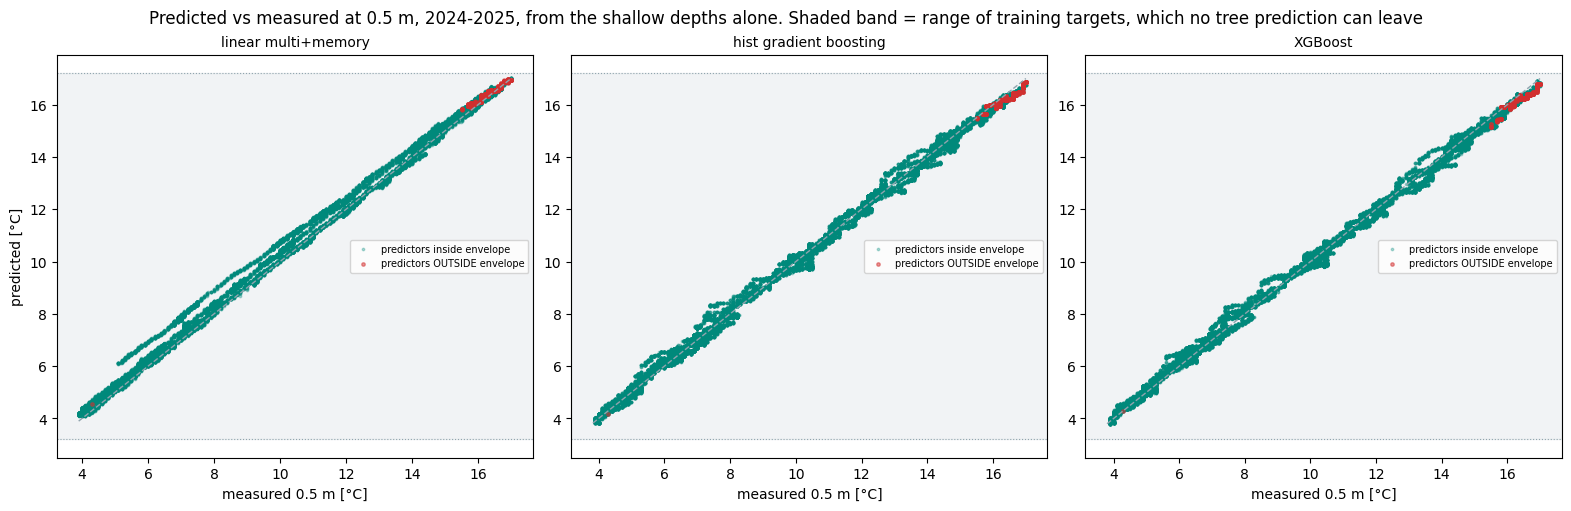

In [12]:
# A picture of the same thing: predicted vs measured at 0.5 m in 2024-2025. Colour is the
# predictor-envelope regime from the table; the horizontal band is the range of training targets,
# which the tree panels cannot leave and the linear panel can. Same fitted predictions as above -
# drawing them does not refit anything.
target = _EXTRAP_TARGET
_inside, _outside = envelope_masks(target, _extr_cands, _extr_tr, _extr_te)
_ytr_lo, _ytr_hi = M[target][_extr_tr].min(), M[target][_extr_tr].max()

fig, axs = plt.subplots(ncols=len(EXTRAP_PRED), figsize=(5.2 * len(EXTRAP_PRED), 5),
                        dpi=100, layout="constrained")
axs = np.atleast_1d(axs)
for ax, (name, pred) in zip(axs, EXTRAP_PRED.items()):
    d = pd.DataFrame({"truth": M[target], "pred": pred,
                      "outside": _outside})[pd.Series(_extr_te, index=full_index)].dropna()
    ins = ~d["outside"].astype(bool)
    ax.scatter(d.loc[ins, "truth"], d.loc[ins, "pred"], s=3, alpha=.3, color="#00897B",
               label="predictors inside envelope")
    ax.scatter(d.loc[~ins, "truth"], d.loc[~ins, "pred"], s=6, alpha=.5, color="#D32F2F",
               label="predictors OUTSIDE envelope")
    _lim = [d[["truth", "pred"]].min().min(), d[["truth", "pred"]].max().max()]
    ax.plot(_lim, _lim, color="#90A4AE", ls="--", lw=1)
    ax.axhspan(_ytr_lo, _ytr_hi, color="#90A4AE", alpha=.12, zorder=0)
    for _v in (_ytr_lo, _ytr_hi):
        ax.axhline(_v, color="#90A4AE", ls=":", lw=.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("measured 0.5 m [°C]")
    ax.legend(fontsize=7)
axs[0].set_ylabel("predicted [°C]")
fig.suptitle("Predicted vs measured at 0.5 m, 2024-2025, from the shallow depths alone. Shaded band "
             "= range of training targets, which no tree prediction can leave", fontsize=12)
plt.show()

## ⏱️ Cost, and the qualitative differences that do not show up in an RMSE

The numbers above are one axis; these are the others, and for a published, auditable product they
weigh as much as a tenth of a kelvin.

The fit times are the ones **actually recorded** during Test 3, not a fresh timing run — measuring
the cost by paying it again was itself part of what made this notebook slow. They are for the
thinned training set when `FAST` is on, so read them as a ratio between models rather than as an
absolute price.

In [13]:
_rows = [{"model": k, "fit_s": round(v, 3), "n_train_rows": None} for k, v in EXTRAP_FIT_S.items()]
_ntr = len(pd.concat([_extr_Xm, M[_EXTRAP_TARGET].rename("y")], axis=1)[_extr_tr]
           .dropna().iloc[::TRAIN_STRIDE])
for r in _rows:
    r["n_train_rows"] = _ntr
display(pd.DataFrame(_rows).set_index("model"))

print("""
Qualitative ledger (independent of the RMSE tables):

  transparency   linear: a per-month slope+intercept with physical units (a damping relation you
                 can print and sanity-check). trees: a black box; 'why is 2013 filled at 8.4 C' has
                 no inspectable answer.
  extrapolation  linear: extrapolates linearly, which is correct for a near-linear conduction
                 relation. trees: clamp to the training range - see Test 3.
  auditability   linear: negative controls and 'recover a known offset' guards, as elsewhere in this
                 repo. trees: hyperparameters, seeds, feature importances - harder to assert on.
  dependency     linear: numpy only. xgboost: a heavy compiled dependency added to a lean uv env.
  overfit risk   linear: none to speak of at this feature count. trees: real; needs held-out tuning
                 that itself has to be defended.
  re-runnability linear: seconds. trees: the reason this notebook needed the treatment above - and
                 a fill nobody can afford to re-validate is a fill nobody can defend.
""")

,fit_s,n_train_rows
model,,
linear multi+memory,0.005,10638
hist gradient boosting,0.236,10638
XGBoost,0.356,10638



Qualitative ledger (independent of the RMSE tables):

  transparency   linear: a per-month slope+intercept with physical units (a damping relation you
                 can print and sanity-check). trees: a black box; 'why is 2013 filled at 8.4 C' has
                 no inspectable answer.
  extrapolation  linear: extrapolates linearly, which is correct for a near-linear conduction
                 relation. trees: clamp to the training range - see Test 3.
  auditability   linear: negative controls and 'recover a known offset' guards, as elsewhere in this
                 repo. trees: hyperparameters, seeds, feature importances - harder to assert on.
  dependency     linear: numpy only. xgboost: a heavy compiled dependency added to a lean uv env.
  overfit risk   linear: none to speak of at this feature count. trees: real; needs held-out tuning
                 that itself has to be defended.
  re-runnability linear: seconds. trees: the reason this notebook needed the treatment above 

## 🧭 Reading the result — the decision rule

Fill in from the tables above; the structure of the answer is fixed even before the numbers are:

1. **Test 1 (a neighbour present).** Expect every method within a few hundredths of a kelvin of the
   others, all near the quantiser floor. If so: for the ~90 % of fills that have an adjacent depth,
   **the model choice is irrelevant** and the simplest one wins by default.

2. **Test 2 (deep from shallow).** Compare three gaps:
   - *nearest-monthly → linear-multi → linear-multi+memory*: this is the gain from **features**
     (more predictors, thermal memory). It is available to the linear fill at zero extra dependency.
   - *linear-multi+memory → XGBoost*: this is the gain from the **model class** alone. If it is
     small (a few hundredths of a K), the ML win is really a feature win, and the right action is to
     **add multi-depth + memory features to the linear fill**, not to adopt XGBoost.
   - only if XGBoost beats the best linear by a **materially useful** margin (say > 0.15 K at a
     depth you care about) is there a case for it — and then only against Test 3. Check the two tree
     rows against each other first: a "win" no larger than the gap between two implementations of
     the same model class is not a win.

3. **Test 3 (extrapolation) is a veto, not a tie-breaker.** A decade-long hole contains temperatures
   the training window did not, and a model that clamps them will bias the filled climate at exactly
   the extremes people study. If the trees show a large one-signed OUTSIDE-envelope bias, that
   **disqualifies them for this use** regardless of their in-sample RMSE.
   - Read `head_room_K` before reading anything else in that section. A two-year test window that
     never leaves its training range cannot exercise the hazard, and a comfortable RMSE there is
     **not** evidence that the clamp is harmless — only that it was not reached. The bound itself is
     not in doubt: it is a property of the model class, and the clamping table shows it holding to
     the last digit. What the test can tell you is how much of it this record happens to touch.

**The most likely honest outcome**, given soil heat conduction is nearly linear and the dominant
missing signal is thermal lag: *the feature upgrade (multi-depth + memory) captures most of the
available gain and belongs in the linear fill; XGBoost adds little on top and loses on
extrapolation, transparency and dependency weight.* If your numbers say otherwise at a specific
depth, that is a targeted, defensible reason to use it **there** — not a reason to swap the whole
fill to a black box.

A concrete, low-regret upgrade this experiment may justify for the product: keep the fill **linear
and era-split**, but let it use **the two nearest available depths plus a 10-30 day rolling mean**
instead of a single instantaneous nearest depth. That is still inspectable, still extrapolates, and
picks up the thermal-memory signal that Test 2 isolates. Decide from the `linear multi+memory`
column whether it is worth the extra code.

In [14]:
print("This notebook wrote nothing. It is an experiment feeding a decision, not a product.")
print("If the decision is 'upgrade the linear fill', the change lives in 10_METEO_TS_FF1's")
print("cross_depth_fill helper; if it is 'adopt a model', that is a larger discussion than a gap-fill.")
print(f"\nRuntime: {time.perf_counter() - NB_T0:.1f}s  (FAST={FAST}, TRAIN_STRIDE={TRAIN_STRIDE})")

This notebook wrote nothing. It is an experiment feeding a decision, not a product.
If the decision is 'upgrade the linear fill', the change lives in 10_METEO_TS_FF1's
cross_depth_fill helper; if it is 'adopt a model', that is a larger discussion than a gap-fill.

Runtime: 34.4s  (FAST=True, TRAIN_STRIDE=6)
